# SENTINEL-WM | Phase 2 - State Windows, ATT&CK Mapping, Sequences

`clean_flows.parquet` -> `state_windows.parquet` -> `sequences.npz`.

This is where per-flow classification becomes **state-trajectory forecasting**.

In [1]:
# bootstrap: make the sentinel_wm package importable without pip install
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root if (_root / 'sentinel_wm').is_dir() else _root.parent
if str(_root) not in sys.path: sys.path.insert(0, str(_root))

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sentinel_wm import config as C, state_windows as SW, sequences as SEQ
from sentinel_wm import attack_stages as A

## 2.1  Build 10-second network-state windows
Each window -> one 41-dim state vector `S_t` (volume, connection dynamics,
TCP-flag rates, timing, Tier-2 packet stats, scan signatures).

In [3]:
sw = SW.build_state_windows(verbose=True)
sw[['day','window_index','flow_count','attack_ratio','progression_state',
    'dominant_family','attck_phase','attck_confidence']].head(12)

[windows] W=10s stride=10s pre_attack_span=3


[windows] 14,644 state windows -> C:\Users\chall\OneDrive\Desktop\SIH\artifacts\state_windows.parquet
[windows] progression_state:
NORMAL          11829
    ACTIVE           1929
    PRE_ATTACK        583
    ONSET             242
    CONTINUATION       61
[windows] y_attack balance: 0.152 positive
[windows] ATT&CK phase x confidence:
attck_phase        attck_confidence
    Command & Control  Low                   405
                       Medium                 79
    Impact             High                  346
                       Medium                151
    Initial Access     Low                   729
                       Medium                391
    Lateral Movement   Low                    34
    None               High                11829
    Reconnaissance     High                   48
                       Low                   583
                       Medium                 49


,day,window_index,flow_count,attack_ratio,progression_state,dominant_family,attck_phase,attck_confidence
0,Friday,0,2.0,0.0,NORMAL,BENIGN,None,High
1,Friday,4,27.0,0.0,NORMAL,BENIGN,None,High
2,Friday,5,81.0,0.0,NORMAL,BENIGN,None,High
3,Friday,6,60.0,0.0,NORMAL,BENIGN,None,High
4,Friday,7,88.0,0.0,NORMAL,BENIGN,None,High
5,Friday,8,74.0,0.0,NORMAL,BENIGN,None,High
6,Friday,9,44.0,0.0,NORMAL,BENIGN,None,High
7,Friday,10,17.0,0.0,NORMAL,BENIGN,None,High
8,Friday,11,119.0,0.0,NORMAL,BENIGN,None,High
9,Friday,12,25.0,0.0,NORMAL,BENIGN,None,High


## 2.2  Progression states (the model's PRIMARY target)
Episodes = runs of attack windows (small gaps bridged). Then:
`NORMAL / PRE_ATTACK / ONSET / ACTIVE / CONTINUATION`.

In [4]:
sw['progression_state'].value_counts()

NORMAL          11829
ACTIVE           1929
PRE_ATTACK        583
ONSET             242
CONTINUATION       61
Name: progression_state, dtype: int64

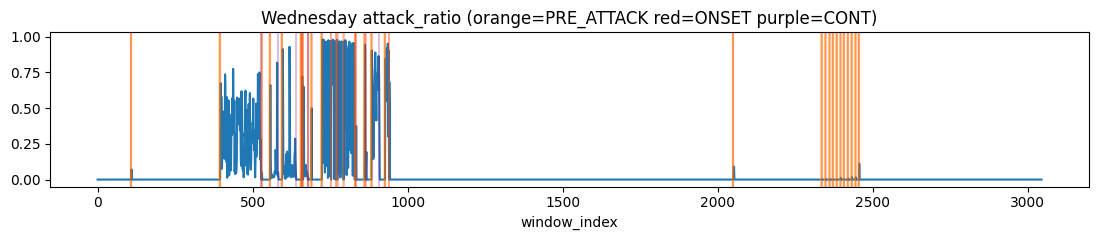

In [5]:
d0 = sw[sw.day=='Wednesday'].set_index('window_index')
ax = d0[['attack_ratio']].plot(figsize=(11,2.5), legend=False)
for st,c in [('PRE_ATTACK','orange'),('ONSET','red'),('CONTINUATION','purple')]:
    for x in d0.index[d0.progression_state==st]: ax.axvline(x,color=c,alpha=.25)
ax.set_title('Wednesday attack_ratio (orange=PRE_ATTACK red=ONSET purple=CONT)'); plt.tight_layout()

## 2.3  MITRE ATT&CK phase mapping (`attack_stages.py`)
CIC-IDS-2017 labels a *flow type*, never a *tactic per moment*. So the map
is a deterministic **two-layer** function applied AFTER the model:

* **Layer A** `CIC_LABEL_TO_ATTACK`: family -> tactic, technique IDs, base confidence
* **Layer B** `assess_window(state, family, prev_family, ratio)`: one phase +
  confidence LOWERED when evidence is thin (PRE_ATTACK, ONSET, low ratio, long horizon).

Every row carries `attck_confidence` in {High, Medium, Low} + a `rationale`.

In [6]:
A._self_test()
for ps in ['NORMAL','PRE_ATTACK','ONSET','ACTIVE','CONTINUATION']:
    a = A.assess_window(ps,'PortScan',prev_family='DoS Hulk',attack_ratio=0.6)
    print(f'{ps:13s} -> {a.kill_chain_phase:22s} {a.confidence:7s} | {a.rationale[:64]}')

attack_stages self-test: PASS
NORMAL        -> None                   High    | window contains only BENIGN flows
PRE_ATTACK    -> Reconnaissance         Medium  | benign-labelled window 3 steps before a confirmed PortScan onset
ONSET         -> Reconnaissance         Medium  | first window carrying a confirmed PortScan label; tactic per kno
ACTIVE        -> Reconnaissance         High    | sustained PortScan activity (attack_ratio=0.60); sequential/rand
CONTINUATION  -> Reconnaissance         Medium  | tactic transition DoS Hulk -> PortScan; adversary changed techni


In [7]:
sw.groupby(['attck_phase','attck_confidence']).size().to_frame('n')

n
attck_phase       attck_confidence       
Command & Control Low                 405
                  Medium               79
Impact            High                346
                  Medium              151
Initial Access    Low                 729
                  Medium              391
Lateral Movement  Low                  34
None              High              11829
Reconnaissance    High                 48
                  Low                 583
                  Medium               49

## 2.4  Sequences + leakage-safe split
`[S_{t-9..t}] -> (S_{t+1}, A_{t+1..6}, Z_{t+1..6})`.

Split = **block-interleaved** across all days: each day cut into 15-min
contiguous blocks, assigned `train,train,train,val,test`. Leakage-safe
(blocks are contiguous, scaler fit on train only) AND every attack family
appears in every split. The strict day split (`mode='day'`) is available
as a harder zero-shot-family benchmark.

In [8]:
seq = SEQ.build_sequences(sw, verbose=True)
print('X', seq['X'].shape, ' y_atk', seq['y_atk'].shape, ' K', int(seq['K']))

[split] mode=block  days=['Friday', 'Monday', 'Thursday', 'Tuesday', 'Wednesday']


[seq] train:   8902 seqs | y_atk(any k)+ = 0.203 | k1+ = 0.141
[seq] val  :   2732 seqs | y_atk(any k)+ = 0.227 | k1+ = 0.189
[seq] test :   2602 seqs | y_atk(any k)+ = 0.225 | k1+ = 0.157
[seq] X shape (14236, 10, 41) -> C:\Users\chall\OneDrive\Desktop\SIH\artifacts\sequences.npz
[seq] scaler -> C:\Users\chall\OneDrive\Desktop\SIH\artifacts\state_scaler.pkl
X (14236, 10, 41)  y_atk (14236, 6)  K 6


In [9]:
sw2 = sw.assign(split=SEQ.assign_split(sw, C.CONFIG.split, C.CONFIG.window, verbose=False))
sw2.groupby('split').agg(windows=('y_attack','size'), attack_frac=('y_attack','mean')).round(3)

,windows,attack_frac
split,,
test,2693,0.161
train,9186,0.139
val,2765,0.190


Next: **`03_model_zoo_and_benchmark.ipynb`**.